**Deep Learning Framework for Leaf Disease Detection and Crop Damage Assessment**

In [1]:
!pip install tensorflow opencv-python scikit-learn matplotlib efficientnet transformers segmentation_models_pytorch

In [2]:
#!conda create -n tf_env python=3.10
#!conda activate tf_env
#!conda install esri::tensorflow-addons

In [3]:
pip install tensorflow-addons==0.22.0

Note: you may need to restart the kernel to use updated packages.


In [4]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import ResNet50, VGG16, EfficientNetB0, InceptionV3, DenseNet121
from keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import cv2
from keras.applications import imagenet_utils

In [5]:
#import tensorflow as tf
#print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

In [6]:
# Load dataset
data_dir = 'C:\\Users\\HP\\OneDrive\\Desktop\\project\\Chapter4 Data\\Code\\PlantVillage'  # Path to the PlantVillage dataset
image_size = (224, 224)

In [7]:
un_healthy_images_list = ['Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Target_Spot',
                                     'Tomato_Late_blight', 'Tomato_Bacterial_spot','Tomato__Tomato_mosaic_virus', 'Tomato_Septoria_leaf_spot',
                                     'Tomato_Early_blight', 'Tomato_Leaf_Mold']

un_healthy_images_list

['Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Target_Spot',
 'Tomato_Late_blight',
 'Tomato_Bacterial_spot',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Early_blight',
 'Tomato_Leaf_Mold']

In [8]:

from PIL import Image

def is_image_file(filename):
    filename = filename.lower()
    return filename.endswith(".jpg") or filename.endswith(".jpeg") or filename.endswith(".png")

def load_dataset(data_dir, image_size, main_dir="C:\\Users\\HP\\OneDrive\\Desktop\\project\\Chapter4 Data\\Code\\PlantVillage"):
    image_data = []
    # labels = []

    for dir in data_dir:
      path = os.path.join(main_dir, dir)
      # print(path)

      imageNames = os.listdir(path)
      # print(imageNames)
      for image in imageNames:
        if not is_image_file(image):
              continue  # Skip non-image files

        image_path = os.path.join(path, image)
        imgs = Image.open(image_path)
        img = np.array(imgs)

        if img is None:
          print(f"Warning: Failed to load image {image}")
          continue  # Skip invalid images

        img = cv2.resize(img, image_size)
        image_data.append(img)
        # labels.append(label)
      # Append the corresponding label

    return np.array(image_data)



In [9]:
data_dir = un_healthy_images_list
image_size = (224, 224)  # Example size
unhealthy_images = load_dataset(data_dir, image_size)
print(unhealthy_images)  # Prints the labels corresponding to each image

[[[[154 144 143]
   [159 149 148]
   [152 142 141]
   ...
   [130 114 114]
   [118 102 102]
   [ 95  79  79]]

  [[160 150 149]
   [161 151 150]
   [148 138 137]
   ...
   [122 106 106]
   [118 102 102]
   [108  92  92]]

  [[155 145 144]
   [159 149 148]
   [149 139 138]
   ...
   [116 100 100]
   [108  92  92]
   [104  88  88]]

  ...

  [[152 141 139]
   [154 143 141]
   [151 140 138]
   ...
   [117  99  97]
   [113  95  93]
   [108  91  89]]

  [[143 132 130]
   [159 148 146]
   [139 128 126]
   ...
   [113  95  93]
   [112  94  92]
   [111  94  92]]

  [[150 139 137]
   [142 131 129]
   [141 130 128]
   ...
   [110  92  90]
   [110  92  90]
   [112  94  92]]]


 [[[146 140 144]
   [156 150 154]
   [163 157 161]
   ...
   [115 104 108]
   [106  95  99]
   [107  96 100]]

  [[139 132 137]
   [147 141 145]
   [148 142 146]
   ...
   [126 115 119]
   [126 115 119]
   [121 110 114]]

  [[148 142 146]
   [142 136 140]
   [147 141 145]
   ...
   [123 112 116]
   [115 104 108]
   [115 104

In [10]:
unhealthy_images.shape

(12744, 224, 224, 3)

In [11]:
np.random.seed(42)  # For reproducibility
indices = np.random.choice(len(unhealthy_images), 1000, replace=False)
unhealthy_images_resized = unhealthy_images[indices]
unhealthy_images_resized.shape

(1000, 224, 224, 3)

In [12]:
unhealthy_labels = np.ones(1000)


In [13]:
healthy_images_list = ["Tomato_healthy"]
healthy_images_list

['Tomato_healthy']

In [14]:
data_dir = healthy_images_list
# print(data_dir)
image_size = (224, 224)  # Example size
healthy_images = load_dataset(data_dir, image_size)
healthy_images

array([[[[132, 131, 137],
         [113, 112, 118],
         [ 99,  98, 104],
         ...,
         [116, 113, 124],
         [134, 131, 142],
         [120, 117, 128]],

        [[116, 115, 121],
         [119, 118, 123],
         [127, 126, 132],
         ...,
         [115, 112, 123],
         [112, 108, 120],
         [124, 121, 132]],

        [[139, 138, 144],
         [137, 136, 142],
         [130, 129, 135],
         ...,
         [111, 107, 118],
         [113, 110, 121],
         [124, 121, 132]],

        ...,

        [[ 69,  73,  77],
         [ 80,  82,  87],
         [ 67,  70,  75],
         ...,
         [ 83,  83,  93],
         [ 74,  74,  84],
         [ 78,  78,  88]],

        [[ 68,  71,  76],
         [ 66,  69,  74],
         [ 58,  61,  66],
         ...,
         [ 76,  76,  86],
         [ 78,  78,  88],
         [ 90,  90, 100]],

        [[ 70,  73,  78],
         [ 56,  59,  64],
         [ 56,  59,  64],
         ...,
         [ 75,  75,  85],
        

In [15]:
healthy_images.shape

(1591, 224, 224, 3)

In [16]:
healthy_labels = np.zeros(1591)
healthy_labels

array([0., 0., 0., ..., 0., 0., 0.])

In [17]:
images = np.concatenate((healthy_images, unhealthy_images_resized), axis=0)
labels = np.concatenate((healthy_labels, unhealthy_labels), axis=0)
print(images.shape)
print(labels.shape)

(2591, 224, 224, 3)
(2591,)


In [18]:
from sklearn.model_selection import train_test_split

In [19]:
images = images / 255.0
X_train, X_val, y_train, y_val = train_test_split(images, labels, test_size=0.2, random_state=42)

# Hibrid Model Resnet+VIT

In [20]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers.experimental import preprocessing
import matplotlib.pyplot as plt

In [21]:
# Number of classes in the dataset
num_classes = 11

# Define the input shape
input_shape = (256, 256, 3)  # Adjust based on your dataset

In [22]:
# Vision Transformer Layer (simplified)
class VisionTransformerLayer(tf.keras.layers.Layer):
    def __init__(self, num_heads=8, key_dim=64, transformer_units=256):
        super(VisionTransformerLayer, self).__init__()
        self.attention = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)
        self.dense_proj = tf.keras.Sequential([
            tf.keras.layers.Dense(transformer_units, activation="relu"),
            tf.keras.layers.Dense(transformer_units),
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    
    def call(self, inputs):
        x = self.layernorm1(inputs)
        attn_output = self.attention(x, x)
        x = attn_output + x
        proj_output = self.dense_proj(self.layernorm2(x))
        return proj_output + x

In [23]:
# ResNet-50 model as feature extractor
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
base_model.trainable = False  # Freeze initial layers

# Fine-tune the last few layers of ResNet
for layer in base_model.layers[-10:]:
    layer.trainable = True

In [24]:
# Define input layer
inputs = Input(shape=input_shape)

In [25]:
# Data augmentation
x = preprocessing.RandomFlip("horizontal")(inputs)
x = preprocessing.RandomRotation(0.1)(x)

In [26]:
# ResNet feature extraction
x = base_model(x, training=False)

In [27]:
from tensorflow.keras.layers import Reshape

In [28]:
# Reduce the dimensionality to match the transformer units
x = Dense(256)(x)  # Project down to 256 dimensions for compatibility with Vision Transformer
x = Reshape((64, 256))(x)  # Adjusted to (num_patches, embed_dim) for Vision Transformer

In [29]:
# Vision Transformer layer for global attention
transformer_output = VisionTransformerLayer()(x)

In [30]:
# Flatten the transformer output
transformer_output = Flatten()(transformer_output)

In [31]:
# Final classification layer
output = Dense(num_classes, activation='softmax')(transformer_output)

In [32]:
# Create and compile the model
hybrid_model = Model(inputs=inputs, outputs=output)
hybrid_model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])


In [33]:
# Summary of the model
hybrid_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 random_flip (RandomFlip)    (None, 256, 256, 3)       0         
                                                                 
 random_rotation (RandomRota  (None, 256, 256, 3)      0         
 tion)                                                           
                                                                 
 resnet50 (Functional)       (None, 8, 8, 2048)        23587712  
                                                                 
 dense (Dense)               (None, 8, 8, 256)         524544    
                                                                 
 reshape (Reshape)           (None, 64, 256)           0         
                                                             

In [34]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [35]:
# Load data using ImageDataGenerator
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Splits data into training and validation sets
)



In [36]:
train_generator = train_datagen.flow_from_directory(
    'C:\\Users\\HP\\OneDrive\\Desktop\\project\\Chapter4 Data\\Code\\PlantVillage\\PlantVillage\\',  # Replace with the path to your dataset
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)


Found 13053 images belonging to 11 classes.


In [37]:

validation_generator = train_datagen.flow_from_directory(
    'C:\\Users\\HP\\OneDrive\\Desktop\\project\\Chapter4 Data\\Code\\PlantVillage\\PlantVillage\\',  # Replace with the path to your dataset
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 3258 images belonging to 11 classes.


In [38]:
# Separate test generator for the 'test' folder
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
     'C:\\Users\\HP\\OneDrive\\Desktop\\project\\Chapter4 Data\\Code\\PlantVillage\\\\PlantVillage\\test',  # Replace with the path to your test dataset
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 300 images belonging to 10 classes.


In [39]:
# Train the model
history = hybrid_model.fit(
    train_generator,
    epochs=40,
    validation_data=validation_generator,
    callbacks=[early_stopping]
)

Epoch 1/40
408/408 [==============================] - 1259s 3s/step - loss: 2.0420 - accuracy: 0.3091 - val_loss: 1.8629 - val_accuracy: 0.3729
Epoch 2/40
408/408 [==============================] - 1249s 3s/step - loss: 1.5464 - accuracy: 0.4846 - val_loss: 1.5679 - val_accuracy: 0.4785
Epoch 3/40
408/408 [==============================] - 1192s 3s/step - loss: 1.3131 - accuracy: 0.5747 - val_loss: 1.3877 - val_accuracy: 0.5467
Epoch 4/40
408/408 [==============================] - 1217s 3s/step - loss: 1.2122 - accuracy: 0.6025 - val_loss: 1.4440 - val_accuracy: 0.5350
Epoch 5/40
408/408 [==============================] - 1172s 3s/step - loss: 1.1155 - accuracy: 0.6333 - val_loss: 1.3164 - val_accuracy: 0.5884
Epoch 6/40
408/408 [==============================] - 1164s 3s/step - loss: 1.0854 - accuracy: 0.6444 - val_loss: 1.5038 - val_accuracy: 0.5371
Epoch 7/40
408/408 [==============================] - 1153s 3s/step - loss: 1.0215 - accuracy: 0.6668 - val_loss: 1.4906 - val_accuracy:

In [40]:
# Plotting the training and validation accuracy/loss
plt.figure(figsize=(14, 5))



<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

Text(0.5, 1.0, 'Training and Validation Accuracy')

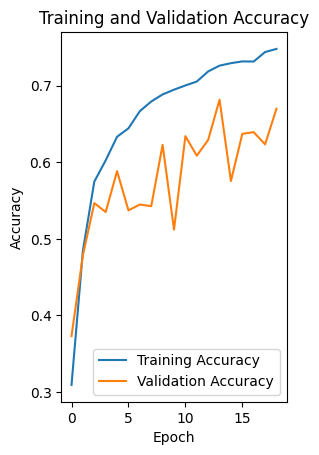

In [41]:
# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')



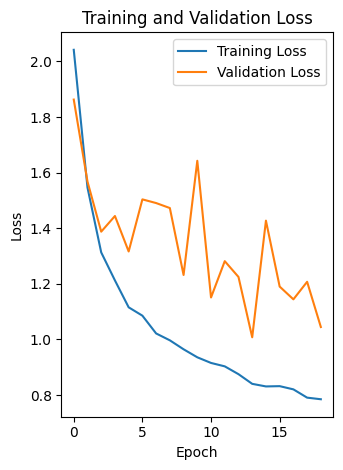

In [42]:
# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

In [43]:
# Evaluate the model on the test set
test_loss, test_accuracy = hybrid_model.evaluate(test_generator)
print(f'Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_loss:.4f}')

InvalidArgumentError: Graph execution error:

Detected at node 'categorical_crossentropy/softmax_cross_entropy_with_logits' defined at (most recent call last):
    File "C:\Users\HP\anaconda31\envs\tf_env\lib\runpy.py", line 196, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "C:\Users\HP\anaconda31\envs\tf_env\lib\runpy.py", line 86, in _run_code
      exec(code, run_globals)
    File "C:\Users\HP\anaconda31\envs\tf_env\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "C:\Users\HP\anaconda31\envs\tf_env\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
      app.start()
    File "C:\Users\HP\anaconda31\envs\tf_env\lib\site-packages\ipykernel\kernelapp.py", line 739, in start
      self.io_loop.start()
    File "C:\Users\HP\anaconda31\envs\tf_env\lib\site-packages\tornado\platform\asyncio.py", line 205, in start
      self.asyncio_loop.run_forever()
    File "C:\User